# Pixel-based Image Search

Sort & filter a folder of images by **brightness, hue, saturation, and visual complexity**.
No ML models — pure PIL + numpy. Handles up to ~60k images comfortably.

**Methods**
1. Sort by brightness
2. Sort by hue (and 2D color plane)
3. Sort by complexity
4. Faceted filter: brightness range × hue range × min saturation × complexity range

Every search shows filenames under the thumbnails and offers a **Download as ZIP** button
where files are renamed with their score (e.g. `0.543_imagename.png`).


## Copyright notice
HSLU DFK | Colabor: Zoom In Zoom Out | 2026 Thomas Knüsel, [MIT License](LICENSE). 
Feel free to modify and reuse the content. 
It would be appreciated if you could mention the source.

## 1. Install & imports

In [1]:
pip install pillow numpy matplotlib tqdm ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import hashlib, pickle, math, zipfile
from datetime import datetime
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import ipywidgets as widgets
from IPython.display import display, FileLink

# === EDIT THIS ===
IMAGE_FOLDER = Path('./Pictures')
CACHE_DIR    = Path('./cache_pixel')
DOWNLOAD_DIR = Path('./downloads')        # where ZIPs of search results land
CACHE_DIR.mkdir(exist_ok=True)
DOWNLOAD_DIR.mkdir(exist_ok=True)
FORCE_RECOMPUTE  = False   # set True to rebuild the cache
DEDUPE_DUPLICATES = True   # collapse files that share size + pixel signature

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}


## Pre-flight — clean the image folder

Move anything that shouldn't be processed into a sibling `*_dump/` folder:
- files whose extension isn't in `IMG_EXTS`
- files PIL can't open (corrupt / truncated)
- exact duplicates (same bytes, MD5-matched) — keeps the first occurrence

Run once before the scan. Re-running is safe: the dump folder lives outside `IMAGE_FOLDER` so it's never re-scanned.


In [ ]:
# Pre-flight cleanup — moves bad files out of IMAGE_FOLDER so they're not processed.
import shutil

DUMP_DIR = IMAGE_FOLDER.parent / f'{IMAGE_FOLDER.name}_dump'
DUMP_DIR.mkdir(exist_ok=True)

def _safe_move(src, dest_dir):
    """Move src into dest_dir, suffixing the name if it already exists."""
    dest = dest_dir / src.name
    n = 1
    while dest.exists():
        dest = dest_dir / f'{src.stem}__{n}{src.suffix}'
        n += 1
    shutil.move(str(src), str(dest))
    return dest

def _file_md5(path, chunk=1 << 20):
    h = hashlib.md5()
    with open(path, 'rb') as f:
        for buf in iter(lambda: f.read(chunk), b''):
            h.update(buf)
    return h.hexdigest()

bad_ext, bad_open, dupes = [], [], []
seen = {}  # md5 -> kept path

all_files = sorted(p for p in IMAGE_FOLDER.rglob('*') if p.is_file())
print(f'scanning {len(all_files)} files in {IMAGE_FOLDER}/ ...')

for p in tqdm(all_files):
    # 1. wrong extension
    if p.suffix.lower() not in IMG_EXTS:
        bad_ext.append(_safe_move(p, DUMP_DIR))
        continue
    # 2. unreadable / corrupt (verify only checks the header — cheap)
    try:
        with Image.open(p) as im:
            im.verify()
    except Exception:
        bad_open.append(_safe_move(p, DUMP_DIR))
        continue
    # 3. exact duplicate
    h = _file_md5(p)
    if h in seen:
        dupes.append((_safe_move(p, DUMP_DIR), seen[h].name))
    else:
        seen[h] = p

print(f'\nmoved to {DUMP_DIR}/:')
print(f'  • {len(bad_ext):>4} non-image extensions')
print(f'  • {len(bad_open):>4} unreadable / corrupt files')
print(f'  • {len(dupes):>4} exact duplicates')
print(f'kept in {IMAGE_FOLDER}/: {len(seen)} unique images')
if dupes:
    print('\nfirst few duplicates (moved → kept):')
    for moved, kept in dupes[:5]:
        print(f'  {moved.name}  →  {kept}')


## 2. Scan folder + compute pixel features

Features per image: **brightness** (luminance), **hue** (dominant, saturation-weighted),
**saturation** (mean), **complexity** (mean gradient magnitude).
All normalized to [0, 1]. Cached to disk keyed by the file list.


In [3]:
def list_images(folder):
    return sorted([p for p in Path(folder).rglob('*') if p.suffix.lower() in IMG_EXTS])

def cache_key(paths):
    h = hashlib.md5()
    for p in paths:
        h.update(str(p).encode())
        try:
            h.update(str(p.stat().st_size).encode())
        except FileNotFoundError:
            pass
    h.update(b'pixel_v2_dedup')
    return h.hexdigest()[:16]

def compute_pixel_features(pil):
    """brightness, dominant hue, saturation, complexity — all in [0, 1]."""
    small = pil.convert('RGB').resize((64, 64))
    arr = np.asarray(small).astype(np.float32) / 255.0
    brightness = float(0.2126*arr[..., 0].mean() + 0.7152*arr[..., 1].mean() + 0.0722*arr[..., 2].mean())
    hsv = np.asarray(small.convert('HSV')).astype(np.float32) / 255.0
    weights = hsv[..., 1].flatten() + 1e-6
    hues    = hsv[..., 0].flatten()
    angles  = hues * 2*np.pi
    x = np.average(np.cos(angles), weights=weights)
    y = np.average(np.sin(angles), weights=weights)
    hue = (math.atan2(y, x) / (2*np.pi)) % 1.0
    sat = float(hsv[..., 1].mean())
    gray = arr.mean(-1)
    gx = np.abs(np.diff(gray, axis=1))
    gy = np.abs(np.diff(gray, axis=0))
    complexity = float((gx.mean() + gy.mean()) / 2)
    return brightness, hue, sat, complexity

def build_index(folder):
    paths = list_images(folder)
    if not paths:
        raise RuntimeError(f'No images found in {folder}')
    key = cache_key(paths)
    cache_file = CACHE_DIR / f'pixel_{key}.pkl'
    if cache_file.exists() and not FORCE_RECOMPUTE:
        print(f'loading cached features: {cache_file.name}')
        with open(cache_file, 'rb') as f:
            return pickle.load(f)
    print(f'computing pixel features for {len(paths)} images...')
    feats, sizes, valid = [], [], []
    for p in tqdm(paths):
        try:
            im = Image.open(p).convert('RGB')
            feats.append(compute_pixel_features(im))
            sizes.append(p.stat().st_size)
            valid.append(p)
        except Exception as e:
            print('skip', p, e)
    feats_arr = np.array(feats, dtype=np.float32)

    if DEDUPE_DUPLICATES and len(valid) > 1:
        # signature: file size + pixel features rounded to 4 decimals
        # both must match for two files to be treated as duplicates
        sigs = [(s, tuple(np.round(f, 4))) for s, f in zip(sizes, feats_arr)]
        seen = {}
        keep = []
        for i, sig in enumerate(sigs):
            if sig not in seen:
                seen[sig] = i
                keep.append(i)
        n_dropped = len(valid) - len(keep)
        if n_dropped:
            print(f'deduped {n_dropped} exact duplicates ({len(valid)} → {len(keep)})')
            valid     = [valid[i] for i in keep]
            feats_arr = feats_arr[keep]

    index = {'paths': valid, 'pixel_feats': feats_arr}
    with open(cache_file, 'wb') as f:
        pickle.dump(index, f)
    print(f'cached to {cache_file}')
    return index

index = build_index(IMAGE_FOLDER)
paths       = index['paths']
pixel_feats = index['pixel_feats']
brightness  = pixel_feats[:, 0]
hue         = pixel_feats[:, 1]
saturation  = pixel_feats[:, 2]
complexity  = pixel_feats[:, 3]
print('images:', len(paths))


computing pixel features for 314 images...


  0%|          | 0/314 [00:00<?, ?it/s]

deduped 1 exact duplicates (314 → 313)
cached to cache_pixel/pixel_0bfe66d6c0200c37.pkl
images: 313


## 3. Display + download helpers

`show_grid` accepts `progress=True` to show a tqdm bar while loading thumbnails (useful for large Top-K).
`make_download_button(get_paths)` returns a button that zips the current result paths into `./downloads/`,
optionally prefixing each filename with its score (e.g. `0.543_imagename.png`).


In [4]:
def _short(name, n=22):
    """Truncate a filename for plot titles."""
    return name if len(name) <= n else name[:n-1] + '…'

def show_grid(image_paths, scores=None, cols=5, thumb=180, figtitle=None,
              show_filenames=True, progress=False):
    n = len(image_paths)
    if n == 0:
        print('(no results)'); return
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*thumb/72, rows*thumb/72))
    axes = np.array(axes).reshape(-1)
    for ax in axes: ax.axis('off')
    iterator = tqdm(enumerate(image_paths), total=n, desc='loading thumbs', leave=False) \
               if progress else enumerate(image_paths)
    for i, p in iterator:
        try:
            im = Image.open(p); im.thumbnail((thumb*2, thumb*2))
            axes[i].imshow(im)
            parts = []
            if scores is not None and i < len(scores):
                parts.append(f'{scores[i]:.3f}')
            if show_filenames:
                parts.append(_short(Path(p).name))
            if parts:
                axes[i].set_title('\n'.join(parts), fontsize=7)
        except Exception as e:
            axes[i].set_title(f'err: {e}', fontsize=7)
    if figtitle: fig.suptitle(figtitle, fontsize=11)
    plt.tight_layout(); plt.show()

def _safe_prefix(s):
    """Sanitize a score/label string for use in a filename."""
    return ''.join(c if c.isalnum() or c in '.+-' else '_' for c in str(s))

def zip_results(paths_list, tag='results', prefixes=None):
    """Zip the given file paths into ./downloads/ and return the zip path.

    If `prefixes` is provided (same length as paths_list), each archived
    filename is prefixed — e.g. prefix='0.543_' on 'cat.png' becomes '0.543_cat.png'.
    """
    if not paths_list:
        print('nothing to download'); return None
    if prefixes is not None and len(prefixes) != len(paths_list):
        raise ValueError('prefixes must match paths_list in length')
    stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
    safe_tag = ''.join(c if c.isalnum() or c in '-_' else '_' for c in tag)[:40]
    zip_path = DOWNLOAD_DIR / f'{safe_tag}_{stamp}.zip'
    with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_STORED) as z:
        seen = {}
        for i, p in enumerate(paths_list):
            base = Path(p).name
            if prefixes is not None:
                base = f'{_safe_prefix(prefixes[i])}{base}'
            if base in seen:
                seen[base] += 1
                stem, suf = Path(base).stem, Path(base).suffix
                arc = f'{stem}_{seen[base]}{suf}'
            else:
                seen[base] = 0
                arc = base
            z.write(p, arcname=arc)
    return zip_path

def make_download_button(get_paths, get_tag=lambda: 'results',
                         get_prefixes=lambda: None,
                         label='Download as ZIP'):
    btn = widgets.Button(description=label, icon='download')
    out = widgets.Output()
    def _on(_):
        out.clear_output()
        with out:
            zp = zip_results(get_paths(), tag=get_tag(), prefixes=get_prefixes())
            if zp is not None:
                print(f'{len(get_paths())} files → {zp}  ({zp.stat().st_size/1e6:.1f} MB)')
                display(FileLink(str(zp)))
                print(f'\n⚠️  Reminder: delete {zp} from ./downloads/ once you have saved it elsewhere — '
                      f'the folder fills up fast.')
    btn.on_click(_on)
    return widgets.VBox([btn, out])


## Method 1 — Sort by brightness

Pick N evenly-spaced samples along the dark→bright axis.


In [5]:
bright_state = {'paths': [], 'prefixes': []}

n_slider = widgets.IntSlider(value=12, min=2, max=50, description='# images')
run_btn  = widgets.Button(description='Show', button_style='primary')
out      = widgets.Output()

def _run(_):
    out.clear_output()
    with out:
        order = np.argsort(brightness)
        picks = np.unique(np.linspace(0, len(order)-1, n_slider.value).astype(int))
        sel = [int(order[i]) for i in picks]
        scores = [float(brightness[i]) for i in sel]
        bright_state['paths']    = [paths[i] for i in sel]
        bright_state['prefixes'] = [f'{s:.3f}_' for s in scores]
        show_grid(bright_state['paths'], scores=scores,
                  cols=min(len(sel), 6),
                  figtitle='dark  ←——————→  bright',
                  progress=n_slider.value >= 12)

run_btn.on_click(_run)
dl = make_download_button(lambda: bright_state['paths'],
                          get_tag=lambda: 'brightness',
                          get_prefixes=lambda: bright_state['prefixes'])
display(widgets.VBox([widgets.HBox([n_slider, run_btn]), out, dl]))


## Method 2 — Sort by hue & 2D color plane

Linear hue sort, plus a scatter plot of hue × saturation with thumbnails.


In [6]:
hue_state = {'paths': [], 'prefixes': []}

n_slider = widgets.IntSlider(value=12, min=2, max=50, description='# images')
run_btn  = widgets.Button(description='Show', button_style='primary')
out      = widgets.Output()

def _run(_):
    out.clear_output()
    with out:
        order = np.argsort(hue)
        picks = np.unique(np.linspace(0, len(order)-1, n_slider.value).astype(int))
        sel = [int(order[i]) for i in picks]
        scores = [float(hue[i]) for i in sel]
        hue_state['paths']    = [paths[i] for i in sel]
        hue_state['prefixes'] = [f'{s:.3f}_' for s in scores]
        show_grid(hue_state['paths'], scores=scores,
                  cols=min(len(sel), 6),
                  figtitle='hue spectrum (red → green → blue → red)',
                  progress=n_slider.value >= 12)

run_btn.on_click(_run)
dl = make_download_button(lambda: hue_state['paths'],
                          get_tag=lambda: 'hue',
                          get_prefixes=lambda: hue_state['prefixes'])
display(widgets.VBox([widgets.HBox([n_slider, run_btn]), out, dl]))


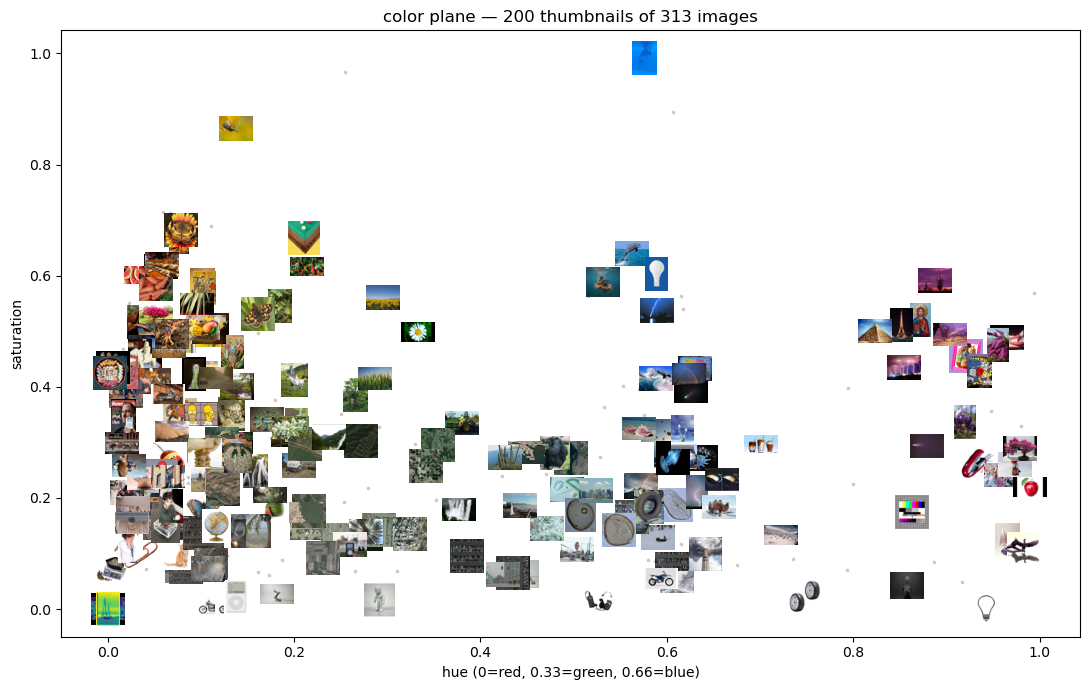

In [7]:
# 2D scatter: hue (x) × saturation (y) with thumbnail overlays on a sample
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

max_thumbs = 200
sample = np.random.default_rng(0).choice(len(paths), size=min(max_thumbs, len(paths)), replace=False)

fig, ax = plt.subplots(figsize=(11, 7))
ax.scatter(hue, saturation, s=3, alpha=0.3, c='gray')
for i in sample:
    try:
        im = Image.open(paths[i]); im.thumbnail((40, 40))
        ab = AnnotationBbox(OffsetImage(im, zoom=0.6), (hue[i], saturation[i]), frameon=False)
        ax.add_artist(ab)
    except Exception:
        pass
ax.set_xlabel('hue (0=red, 0.33=green, 0.66=blue)')
ax.set_ylabel('saturation')
ax.set_title(f'color plane — {len(sample)} thumbnails of {len(paths)} images')
plt.tight_layout(); plt.show()


## Method 3 — Sort by visual complexity

Mean gradient magnitude. Low = flat/minimalist, high = textured/busy.


In [8]:
cx_state = {'paths': [], 'prefixes': []}

n_slider = widgets.IntSlider(value=12, min=2, max=50, description='# images')
run_btn  = widgets.Button(description='Show', button_style='primary')
out      = widgets.Output()

def _run(_):
    out.clear_output()
    with out:
        order = np.argsort(complexity)
        picks = np.unique(np.linspace(0, len(order)-1, n_slider.value).astype(int))
        sel = [int(order[i]) for i in picks]
        scores = [float(complexity[i]) for i in sel]
        cx_state['paths']    = [paths[i] for i in sel]
        cx_state['prefixes'] = [f'{s:.3f}_' for s in scores]
        show_grid(cx_state['paths'], scores=scores,
                  cols=min(len(sel), 6),
                  figtitle='minimal  ←——————→  busy',
                  progress=n_slider.value >= 12)

run_btn.on_click(_run)
dl = make_download_button(lambda: cx_state['paths'],
                          get_tag=lambda: 'complexity',
                          get_prefixes=lambda: cx_state['prefixes'])
display(widgets.VBox([widgets.HBox([n_slider, run_btn]), out, dl]))


## Method 4 — Faceted filter

Combine all four dimensions with range sliders. Hue wraps, so you can set e.g. 0.9→0.1 to catch reds on both sides of 0.
Files in the zip are prefixed with brightness (the sort key).


In [9]:
facet_state = {'paths': [], 'prefixes': []}

br_range  = widgets.FloatRangeSlider(value=[0.0, 1.0], min=0, max=1, step=0.01, description='Brightness')
hue_range = widgets.FloatRangeSlider(value=[0.0, 1.0], min=0, max=1, step=0.01, description='Hue')
sat_min   = widgets.FloatSlider(value=0.0, min=0, max=1, step=0.01, description='Min sat')
cx_range  = widgets.FloatRangeSlider(value=[0.0, 1.0], min=0, max=1, step=0.01, description='Complexity')
topk_box  = widgets.IntSlider(value=12, min=1, max=50, description='Top K')
run_btn   = widgets.Button(description='Filter', button_style='primary')
out       = widgets.Output()

def _run(_):
    out.clear_output()
    with out:
        b0, b1 = br_range.value
        h0, h1 = hue_range.value
        c0, c1 = cx_range.value
        mask = (brightness >= b0) & (brightness <= b1) \
             & (saturation >= sat_min.value) \
             & (complexity >= c0) & (complexity <= c1)
        if h0 <= h1:
            mask &= (hue >= h0) & (hue <= h1)
        else:
            mask &= (hue >= h0) | (hue <= h1)
        hits = np.where(mask)[0]
        print(f'{len(hits)} matches')
        if len(hits) == 0: return
        hits = hits[np.argsort(brightness[hits])][:topk_box.value]
        sel    = [int(i) for i in hits]
        scores = [float(brightness[i]) for i in sel]
        facet_state['paths']    = [paths[i] for i in sel]
        facet_state['prefixes'] = [f'{s:.3f}_' for s in scores]
        # show_grid uses one score per image; build a richer caption manually
        titles_scores = [
            float(brightness[i]) for i in sel
        ]
        # call show_grid with brightness as the 'score' line; filename will follow
        show_grid(facet_state['paths'], scores=titles_scores,
                  figtitle='faceted (sorted by brightness)',
                  progress=topk_box.value >= 12)

run_btn.on_click(_run)
dl = make_download_button(lambda: facet_state['paths'],
                          get_tag=lambda: 'faceted',
                          get_prefixes=lambda: facet_state['prefixes'])
display(widgets.VBox([br_range, hue_range, sat_min, cx_range,
                      widgets.HBox([topk_box, run_btn]), out, dl]))
